# Question 7 - Naive Bayes Warm-Up

Problems:
1. Bayes rule with a diagnostic test.
2. Binary Naive Bayes on a small dataset; classify x = (1,1).

## 1. Drug Test Bayes Calculation
Given: 

$P(T=1|D=1) = 0.99$

$P(T=0|D=0) = 0.99$ $\Rightarrow$ $P(T=1|D=0)=0.01$

$P(D=1)=0.001$ $\Rightarrow$ $P(D=0)=0.999$

$\Rightarrow$ $P(D=1|T=1)$ = $\frac{P(T=1|D=1)P(D=1)} {P(T=1|D=1)P(D=1) + P(T=1|D=0)P(D=0)}$
 =  $\frac{0.99 * 0.001}{0.00099 + 0.00999}$ $\approx$ $0.0901639$ $\approx$ 9%

In [1]:
p_t_pos_d_pos = 0.99
p_t_neg_d_neg = 0.99
p_t_pos_d_neg = 1 - p_t_neg_d_neg
p_d_pos = 0.001
p_d_neg = 1 - p_d_pos
p_d_pos_t_pos = p_t_pos_d_pos * p_d_pos / (p_t_pos_d_pos * p_d_pos + p_t_pos_d_neg * p_d_neg)
p_d_pos_t_pos

0.09016393442622944

## 2. Naive Bayes Classification
Assumed reconstruction (10 examples, 2 binary features X, label y)

Test example: x = (1,1)

In [2]:
import numpy as np
X = np.array([
    [0,1],
    [1,1],
    [0,0],
    [1,1],
    [1,1],
    [0,0],
    [1,0],
    [1,0],
    [1,1],
    [1,0]
])
y = np.array([1,1,0,1,1,0,0,0,1,0])
X.shape, y.shape

((10, 2), (10,))

### (a) Class priors
Counts: y=1 appears 5 times, y=0 appears 5 times

$P(y=1)=0.5$,  $P(y=0)=0.5$

In [3]:
p_y1 = np.mean(y==1)
p_y0 = np.mean(y==0)
p_y1, p_y0

(np.float64(0.5), np.float64(0.5))

### (b) Conditional probabilities
For $y=1$ rows: (0,1),(1,1),(1,1),(1,1),(1,1)

$x_1=1$ count = 4 $\Rightarrow$ $P(x_1=1|y=1)=0.8$

$x_2=1$ count = 5 $\Rightarrow$ $P(x_2=1|y=1)=1.0$

---

For $y=0$ rows: (0,0),(0,0),(1,0),(1,0),(1,0)

$x_1=1$ count = 3 $\Rightarrow$ $P(x_1=1|y=0)$=0.6

$x_2=1$ count = 0 $\Rightarrow$ $P(x_2=1|y=0)$=0.0

In [4]:
X_y1 = X[y==1]
X_y0 = X[y==0]
p_x1_1_y1 = np.mean(X_y1[:,0]==1)
p_x2_1_y1 = np.mean(X_y1[:,1]==1)
p_x1_1_y0 = np.mean(X_y0[:,0]==1)
p_x2_1_y0 = np.mean(X_y0[:,1]==1)
p_x1_1_y1, p_x2_1_y1, p_x1_1_y0, p_x2_1_y0

(np.float64(0.8), np.float64(1.0), np.float64(0.6), np.float64(0.0))

### (c) Classification
Score(y=1) $\Rightarrow$ $0.5 * 0.8 * 1.0 = 0.4$

Score(y=0) $\Rightarrow$ $0.5 * 0.6 * 0.0 = 0.0$

So the predict is $y=1$

In [5]:
x_test = np.array([1,1])
score_y1 = p_y1 * (p_x1_1_y1 if x_test[0]==1 else 1-p_x1_1_y1) * (p_x2_1_y1 if x_test[1]==1 else 1-p_x2_1_y1)
score_y0 = p_y0 * (p_x1_1_y0 if x_test[0]==1 else 1-p_x1_1_y0) * (p_x2_1_y0 if x_test[1]==1 else 1-p_x2_1_y0)
predict = 1 if score_y1>score_y0 else 0
score_y1, score_y0, predict

(np.float64(0.4), np.float64(0.0), 1)

# Question 8 - Classifying Spam with Naive Bayes


This notebook implements a Naive Bayes classifier for spam detection on the TREC Public Spam Corpus subset provided.

It will:
- Parse the given train and test files .
- Compute priors $P(spam)$, $P(ham)$.
- Compute conditional probabilities $P(w|class)$ using the m-estimate: $m = |V|$, $p = \frac{1}{|V|}$ .
- Report the 5 most likely words given spam and ham.
- Classify test emails with log probabilities and report accuracy.
- Sweep $m = |V| × [1, 10, 100, 1000, 10000]$ and plot accuracy vs m.

## 1) Parsing the data

Base on data format, we will parse each line into `(doc_id, label, {word:count})`.

We always interpret pairs `(token[i], token[i+1])` as `(word, integer count)`.

If a count can't be parsed to int, we skip that pair.

In [6]:
from collections import defaultdict
import math
import matplotlib.pyplot as plt

def parse_line(line):
    line = line.strip()
    parts = line.split()
    doc_id = parts[0]
    label = parts[1]
    wc = {}
    
    i = 2
    while i + 1 < len(parts):
        w = parts[i]
        c_str = parts[i + 1]

        try:
            c = int(c_str)
        except ValueError:
            i += 1
            continue

        if c > 0:
            wc[w] = wc.get(w, 0) + c

        i += 2

    return doc_id, label, wc

def load_dataset(path):
    docs = []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parsed = parse_line(line)
            if parsed is not None:
                docs.append(parsed)
                
    return docs

In [7]:
TRAIN_PATH = r"./Data/train" 
TEST_PATH  = r"./Data/test"
train_docs = load_dataset(TRAIN_PATH)
test_docs  = load_dataset(TEST_PATH)

print(f"Loaded train: {len(train_docs)} docs, test: {len(test_docs)} docs")
print("Example line parsed:", train_docs[0])

Loaded train: 9000 docs, test: 1000 docs
Example line parsed: ('/000/003', 'ham', {'need': 1, 'fw': 1, '35': 2, '39': 1, 'thanks': 1, 'thread': 2, '40': 1, 'copy': 1, 'else': 1, 'correlator': 1, 'under': 1, 'companies': 1, '25': 1, 'he': 2, '26': 2, '168': 1, '29': 2, 'content': 4, '1': 1, '6': 1, '5': 1, '4': 1, 'review': 2, 'we': 1, 'john': 3, '17': 1, 'use': 1, '15': 1, '20': 1, 'classes': 1, 'may': 1, 'a': 1, 'back': 1, 'l': 1, '01': 1, 'produced': 1, 'i': 1, 'yes': 1, '10': 2, '713': 2, 'v6': 1, 'p': 1, 'original': 2, 'doc': 2, '2001': 4, 'comments': 1, 'x': 3, 'week': 1, 'to': 6, 'harry': 2, '110': 1, 'smtpsvc': 1, 'has': 1, 'who': 1, 'sender': 1, 'would': 1, 'any': 2, 'jan': 5, 'be': 1, 'index': 1, 'text': 1, 'intended': 1, 'and': 2, 'urn': 1, 'email': 2, 'cc': 1, '1600': 1, 'can': 1, 're': 2, 'corp': 3, 'fri': 2, 'response': 1, '65': 1, 'plain': 1, 'confidential': 1, '853': 1, 'you': 6, 'mailto': 1, 'anything': 1, 'am': 1, 'our': 3, 'they': 1, 'for': 6, 'info': 1, 'of': 2, 'are

## 2) Compute priors P(spam), P(ham)
We estimate priors by relative frequencies in the training set.

In [8]:
num_spam = sum(1 for _, label, _ in train_docs if label == 'spam')
num_ham = sum(1 for _, label, _ in train_docs if label == 'ham')
total = num_spam + num_ham

print("Number of spams:", num_spam)
print("Number of hams:", num_ham)

P_spam = num_spam / total
P_ham = num_ham / total

print(f"P(spam) = {P_spam:.6f}")
print(f"P(ham)  = {P_ham:.6f}")

Number of spams: 5163
Number of hams: 3837
P(spam) = 0.573667
P(ham)  = 0.426333


## 3) Vocabulary and conditional probabilities with m-estimate
We build the vocabulary from the training set, and compute word counts per class and total tokens per class.

m-estimate for multinomial Naive Bayes:
- Let $m =$ |Vocabulary|
- $p = \frac{1}{|V|}$
- For each class c and each word w, with word-count $n(w, c)$ and total tokens $N(c)$:

  $P(w|c) = (n(w, c) + m p) / (N(c) + m)$

In [9]:
def build_counts_and_vocab(docs):
    wc_spam = defaultdict(int)
    wc_ham  = defaultdict(int)
    total_spam_tokens = 0
    total_ham_tokens  = 0
    vocab = set()
    
    for _, label, wc in docs:
        if label == 'spam':
            for w, c in wc.items():
                wc_spam[w] += c
                total_spam_tokens += c
                vocab.add(w)
        else:
            for w, c in wc.items():
                wc_ham[w] += c
                total_ham_tokens += c
                vocab.add(w)
    return wc_spam, wc_ham, total_spam_tokens, total_ham_tokens, vocab

wc_spam, wc_ham, N_spam, N_ham, vocab = build_counts_and_vocab(train_docs)
V = len(vocab)
print(f"Vocab size: {V}")
print(f"Total spam tokens: {N_spam}, total ham tokens: {N_ham}")

Vocab size: 1000
Total spam tokens: 1655369, total ham tokens: 1577820


Function to compute log P(w|c) given m (and p=1/|V|), and helper to get top-k words by conditional probability per class.

In [20]:
def compute_log_conditional_probs(wc_class, N_class, V, m):
    p = 1.0 / V
    denom = N_class + m
    
    unknown_logp = math.log((m * p) / denom)

    log_probs = {}
    for w in vocab:
        num = wc_class.get(w, 0) + m * p
        log_probs[w] = math.log(num / denom)
    return log_probs, unknown_logp

def top_k_words(log_probs, k=5):
    items = sorted(log_probs.items(), key=lambda x: x[1], reverse=True)
    return items[:k]

m_default = V
logP_w_spam, unk_spam = compute_log_conditional_probs(wc_spam, N_spam, V, m_default)
logP_w_ham, unk_ham  = compute_log_conditional_probs(wc_ham,  N_ham,  V, m_default)

print("Top 5 words given spam:")
for w, lp in top_k_words(logP_w_spam, k=5):
    print(f"{w}: {math.exp(lp):.6e}")

print("\nTop 5 words given ham:")
for w, lp in top_k_words(logP_w_ham, k=5):
    print(f"{w}: {math.exp(lp):.6e}")

Top 5 words given spam:
enron: 3.819439e-02
a: 2.361853e-02
corp: 2.173791e-02
the: 2.142518e-02
to: 1.968704e-02

Top 5 words given ham:
aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa: 4.432171e-02
enron: 4.244372e-02
the: 3.316908e-02
to: 2.532968e-02
a: 1.773666e-02


## 4) Classify the test set and report accuracy
We compare:
$[ \log P(c) + \sum_{(w, count) \in d} count \cdot \log P(w|c) ]$
for $c \in$ {spam, ham}, and choose the class with higher log-score.

We only sum over words that appear in the document; unseen words use the smoothed unknown log-prob for that class.


In [11]:
def classify_doc(word_counts, logP_w_spam, logP_w_ham, unk_spam, unk_ham, logP_spam, logP_ham):
    s_spam = logP_spam
    s_ham = logP_ham
    for w, c in word_counts.items():
        s_spam += c * logP_w_spam.get(w, unk_spam)
        s_ham += c * logP_w_ham.get(w, unk_ham)
    return 'spam' if s_spam > s_ham else 'ham'

def evaluate(test_docs, logP_w_spam, logP_w_ham, unk_spam, unk_ham, P_spam, P_ham):
    logP_spam = math.log(P_spam if P_spam > 0 else 1e-15)
    logP_ham = math.log(P_ham if P_ham  > 0 else 1e-15)
    correct = 0
    for _, true_label, wc in test_docs:
        pred = classify_doc(wc, logP_w_spam, logP_w_ham, unk_spam, unk_ham, logP_spam, logP_ham)
        if pred == true_label:
            correct += 1
    return correct / len(test_docs) if test_docs else 0.0

acc_default = evaluate(test_docs, logP_w_spam, logP_w_ham, unk_spam, unk_ham, P_spam, P_ham,)
print(f"Accuracy with m = |V|: {acc_default:.4f}")

Accuracy with m = |V|: 0.9020


## 5) Vary m and plot accuracy vs. m
This helps visualize the effect of smoothing strength on performance.

Interpretation of m:
- Very small m: model trusts empirical counts heavily (can overfit to training token frequencies).
- Very large m: model pulls $P(w|c)$ toward uniform $\frac{1}{|V|}$ (underfits, class conditional distributions look similar).

In practice, a moderate m often performs best: it regularizes estimates for low-frequency words without washing out truly discriminative words.

m = 1000 (factor 1) => accuracy = 0.9020
m = 10000 (factor 10) => accuracy = 0.9040
m = 100000 (factor 100) => accuracy = 0.9040
m = 1000000 (factor 1000) => accuracy = 0.8710
m = 10000000 (factor 10000) => accuracy = 0.7650


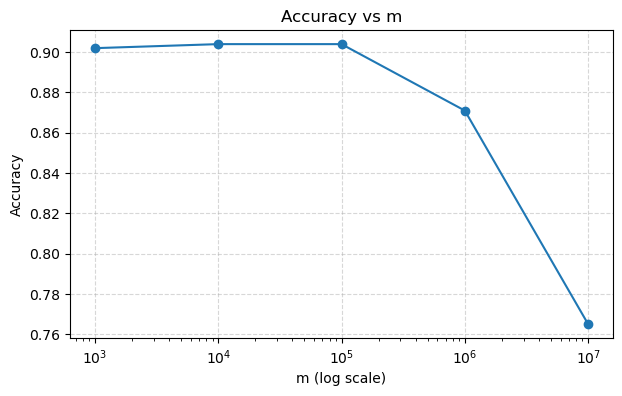

In [12]:
factors = [1, 10, 100, 1000, 10000]
ms = [V * f for f in factors]
accs = []

for m in ms:
    logP_w_spam_m, unk_spam_m = compute_log_conditional_probs(wc_spam, N_spam, V, m)
    logP_w_ham_m, unk_ham_m = compute_log_conditional_probs(wc_ham, N_ham, V, m)
    acc_m = evaluate(test_docs, logP_w_spam_m, logP_w_ham_m, unk_spam_m, unk_ham_m, P_spam, P_ham)
    accs.append(acc_m)
    print(f"m = {m} (factor {m//V}) => accuracy = {acc_m:.4f}")

plt.figure(figsize=(7,4))
plt.semilogx(ms, accs, marker='o')
plt.xlabel('m (log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs m')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 6) If I were a spammer
- Add many common ham-like tokens to drag the document’s log-likelihood toward ham.
- Break words up, insert punctuation, replace letters with lookalikes, so exact token matches drop and smoothing dominates.
- Embed text in images, or use HTML tricks to hide text while showing human readable content.
- Vary vocabulary frequently to avoid stable word-frequency patterns.

# Question 9 - Cloud vs. Clear Sky



Our data pattern: 

Cloudy $\Rightarrow$ mostly gray sky

Clear $\Rightarrow$ warm sunset colors (orange, red, yellow).

We build three classifiers that use counts and averages of the red (R), green (G), and blue (B) values:

- Model A: Gray vs Warm fraction (top of image emphasis):
  - gray top = fraction of pixels in the top 40% with R, G, B nearly equal and average brightness not too dark.
  - warm all = fraction of pixels in the whole image that look orange or yellow (R high, B clearly lower, G moderately high).
  - cloud_score = gray_top − 0.5 × warm_all. Larger $\Rightarrow$ cloudier.

- Model B: Average Red minus Blue:
  - avg_R and avg_B are image-wide averages of R and B.
  - cloud_score = (avg_B − avg_R). If the image is warm, avg_R > avg_B, so the score is smaller (clear). Larger (cloudy).

- Model C: Gray to Warm ratio:
  - gray_all = fraction of gray pixels in the whole image.
  - warm_all as above.
  - cloud score = gray_all / (warm_all + $\epsilon$). Larger $\Rightarrow$ cloudier.

For each model we search a simple threshold on its score that gives the best accuracy on our labeled set. We then report confusion matrix, precision, recall, and show misclassified images.


In [13]:
import os, glob, math
from dataclasses import dataclass
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = r"./Images"
POS_LABEL = 'c'  
NEG_LABEL = 's'
print("DATA_DIR:", DATA_DIR)

DATA_DIR: ./Images


## Load labeled images

In [14]:
def load_paths(data_dir):
    pairs = []
    for p in sorted(glob.glob(os.path.join(data_dir, "*.jpg"))):
        name = os.path.basename(p).lower()
        if (name.startswith('c')):
            pairs.append((p, 'c'))
        elif (name.startswith('s')):
            pairs.append((p, 's'))
    return pairs

pairs = load_paths(DATA_DIR)
print(f"Found {len(pairs)} labeled images.")

Found 80 labeled images.


## Basic image helpers
- Resize the longer side to 512 px for speed.
- Convert to an array in [0,1].
- Simple masks to detect gray and warm (orange/yellow) pixels using only R, G, B comparisons.

In [15]:
def load_image(path, max_side= 512):
    img = Image.open(path).convert('RGB')
    w, h = img.size
    scale = min(1.0, max_side / max(w, h))
    if scale < 1.0:
        img = img.resize((int(w*scale), int(h*scale)), Image.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0

def gray_mask(rgb, diff_tol = 0.08, min_avg = 0.25):
    r, g, b = rgb[...,0], rgb[...,1], rgb[...,2]
    mx = np.maximum(np.maximum(r, g), b)
    mn = np.minimum(np.minimum(r, g), b)
    avg = (r + g + b) / 3.0
    close = (mx - mn) < diff_tol
    bright_enough = avg > min_avg
    return close & bright_enough

def warm_mask(rgb):
    r, g, b = rgb[...,0], rgb[...,1], rgb[...,2]
    return (r > 0.40) & (r > b + 0.15) & (g > b + 0.05)

def top_region(rgb, top_frac= 0.4):
    h = rgb.shape[0]
    t = int(h * top_frac)
    return rgb[:max(1, t), :, :]


## Feature extraction (plain words)
- gray_top: percent of gray pixels in the top 40% (where sky usually is)
- gray_all: percent of gray pixels in the whole image
- warm_all: percent of warm (orange/yellow) pixels in the whole image
- avg_R, avg_B: simple averages of the red and blue values over the whole image
- rb_diff: avg_R − avg_B (bigger $\Rightarrow$ warmer overall)

In [16]:
@dataclass
class Sample:
    path: str
    label: str
    gray_top: float
    gray_all: float
    warm_all: float
    avg_R: float
    avg_B: float
    rb_diff: float

def compute_features(path):
    img = load_image(path, max_side=512)
    top = top_region(img, 0.4)
    gmask_top = gray_mask(top)
    gmask_all = gray_mask(img)
    wmask_all = warm_mask(img)
    gray_top = float(np.mean(gmask_top))
    gray_all = float(np.mean(gmask_all))
    warm_all = float(np.mean(wmask_all))
    avg_R = float(np.mean(img[...,0]))
    avg_B = float(np.mean(img[...,2]))
    rb_diff = float(avg_R - avg_B)
    return gray_top, gray_all, warm_all, avg_R, avg_B, rb_diff

samples = []
for p, label in pairs:
    gray_top, gray_all, warm_all, avg_R, avg_B, rb_diff = compute_features(p)
    samples.append(Sample(p, label, gray_top, gray_all, warm_all, avg_R, avg_B, rb_diff))

print(f"Computed features for {len(samples)} images.")


Computed features for 80 images.


## Three simple models (each returns a single score)
- Model A score = gray_top − 0.5 × warm_all
- Model B score = (avg_B − avg_R)  (bigger means less warm $\Rightarrow$ cloudier)
- Model C score = gray_all / (warm_all + tiny)

In [17]:
EPS = 1e-6

def score_model_A(s):
    return s.gray_top - 0.5 * s.warm_all

def score_model_B(s):
    return s.avg_B - s.avg_R

def score_model_C(s):
    return s.gray_all / (s.warm_all + EPS)

labels = [s.label for s in samples]
scores_A = np.array([score_model_A(s) for s in samples])
scores_B = np.array([score_model_B(s) for s in samples])
scores_C = np.array([score_model_C(s) for s in samples])
print("Score samples (A,B,C):", scores_A[:3], scores_B[:3], scores_C[:3])

Score samples (A,B,C): [0.9767293  0.08408468 0.14917289] [0.0119732  0.23840022 0.08724374] [2.15877510e+01 2.55538997e+05 9.28212441e+00]


## Threshold search and evaluation
We pick a threshold that makes the most correct predictions on the current labeled set. Cloudy is the positive class.

In [18]:
def find_best_threshold(scores, labels, larger_means_cloudy):
    y = np.array([1 if L == POS_LABEL else 0 for L in labels], dtype=int)
    if scores.size == 0:
        return 0.0, 0.0
    candidates = np.unique(np.percentile(scores, np.linspace(0, 100, num=min(201, max(5, scores.size))), method='nearest'))
    best_t, best_acc = None, -1.0
    for t in candidates:
        pred = (scores > t) if larger_means_cloudy else (scores < t)
        acc = (pred.astype(int) == y).mean()
        if acc > best_acc:
            best_acc, best_t = acc, float(t)
    return best_t, best_acc

def predict(scores, t, larger_means_cloudy):
    cond = (scores > t) if larger_means_cloudy else (scores < t)
    return [POS_LABEL if b else NEG_LABEL for b in cond]

def metrics(y_true, y_pred):
    tp = sum((yt==POS_LABEL and yp==POS_LABEL) for yt, yp in zip(y_true, y_pred))
    tn = sum((yt==NEG_LABEL and yp==NEG_LABEL) for yt, yp in zip(y_true, y_pred))
    fp = sum((yt==NEG_LABEL and yp==POS_LABEL) for yt, yp in zip(y_true, y_pred))
    fn = sum((yt==POS_LABEL and yp==NEG_LABEL) for yt, yp in zip(y_true, y_pred))
    prec = tp / (tp + fp) if (tp+fp)>0 else 0.0
    rec = tp / (tp + fn) if (tp+fn)>0 else 0.0
    acc = (tp + tn) / max(1, (tp+tn+fp+fn))
    return (tp, fp, fn, tn), prec, rec, acc

tA, accA_fit = find_best_threshold(scores_A, labels, larger_means_cloudy=True)
tB, accB_fit = find_best_threshold(scores_B, labels, larger_means_cloudy=True)
tC, accC_fit = find_best_threshold(scores_C, labels, larger_means_cloudy=True)

pred_A = predict(scores_A, tA, True)
pred_B = predict(scores_B, tB, True)
pred_C = predict(scores_C, tC, True)

def print_report(name, labels, preds):
    cm, prec, rec, acc = metrics(labels, preds)
    tp, fp, fn, tn = cm
    print(name)
    print(f"  Confusion (pos=cloudy): TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Precision={prec:.4f}  Recall={rec:.4f}  Accuracy={acc:.4f}")

print(f"Model A threshold: {tA:.4f}")
print_report("Model A — Gray vs Warm (top emphasis)", labels, pred_A)
print(f"\nModel B threshold: {tB:.4f}")
print_report("Model B — Avg Blue minus Red", labels, pred_B)
print(f"\nModel C threshold: {tC:.4f}")
print_report("Model C — Gray/Warm ratio", labels, pred_C)


Model A threshold: -0.0150
Model A — Gray vs Warm (top emphasis)
  Confusion (pos=cloudy): TP=32, FP=4, FN=8, TN=36
  Precision=0.8889  Recall=0.8000  Accuracy=0.8500

Model B threshold: -0.1513
Model B — Avg Blue minus Red
  Confusion (pos=cloudy): TP=34, FP=6, FN=6, TN=34
  Precision=0.8500  Recall=0.8500  Accuracy=0.8500

Model C threshold: 2.2817
Model C — Gray/Warm ratio
  Confusion (pos=cloudy): TP=30, FP=0, FN=10, TN=40
  Precision=1.0000  Recall=0.7500  Accuracy=0.8750


## Show misclassified images

We used very plain rules:
- Cloudy score grows with number of gray pixels (R≈G≈B) near top.
- Clear score (opposite) grows with warm sunset pixels (red high, blue lower).


Misclassification patterns:
- Sunset but Cloudy (false clear $\Rightarrow$ predicted s when true is c):
   - Clouds are lit by sunset and turn orange/red.
   - Our warm pixel rule treats those bright warm cloud patches like clear sky.
   - Gray fraction (especially at top) decreases because colored clouds are no longer “gray”.
   Cause: Clouds lose their gray signature when colored by sun.

Misclassified: 12


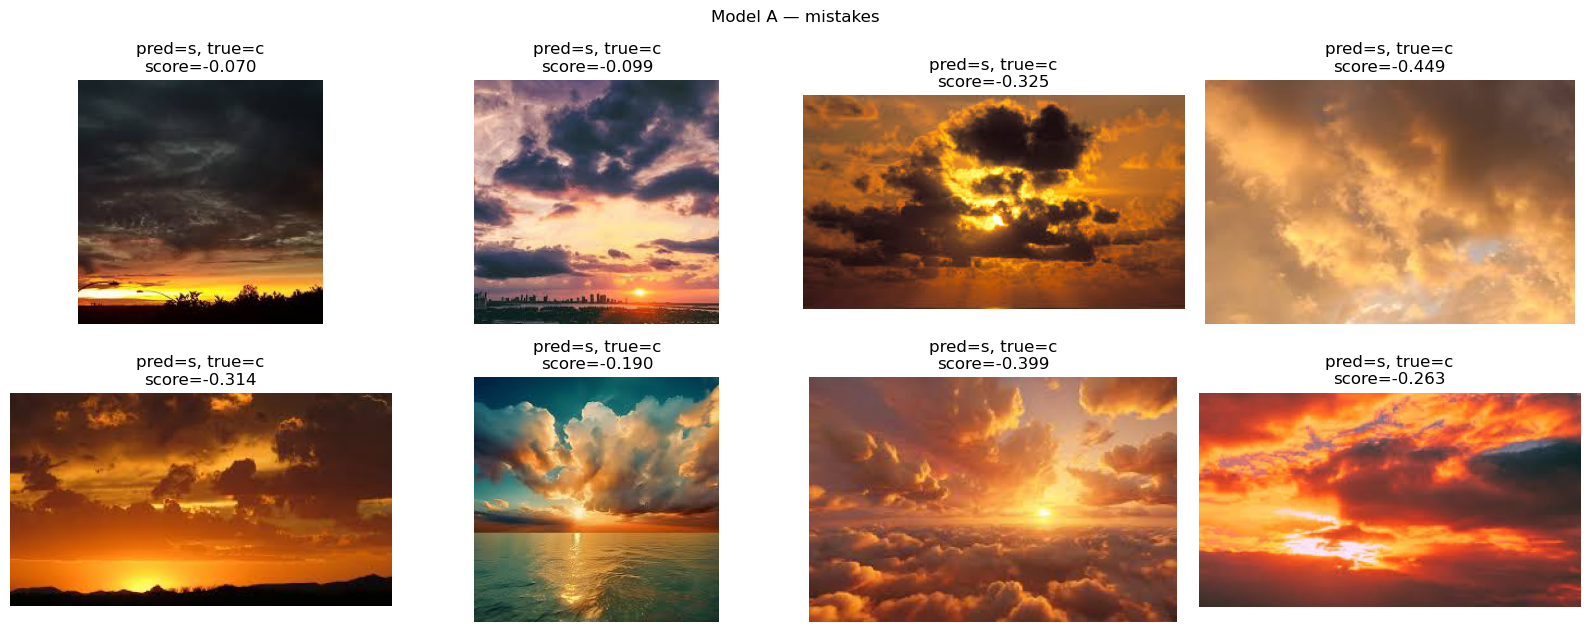

Misclassified: 12


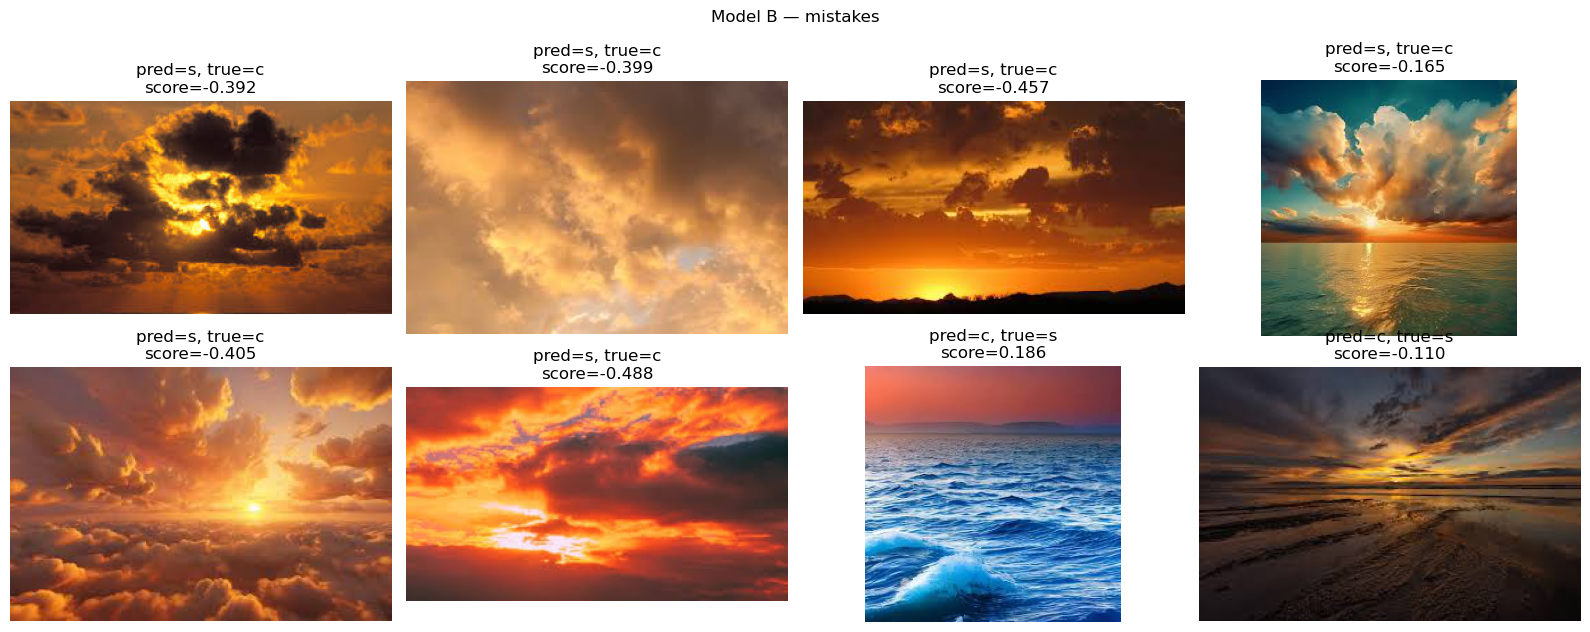

Misclassified: 10


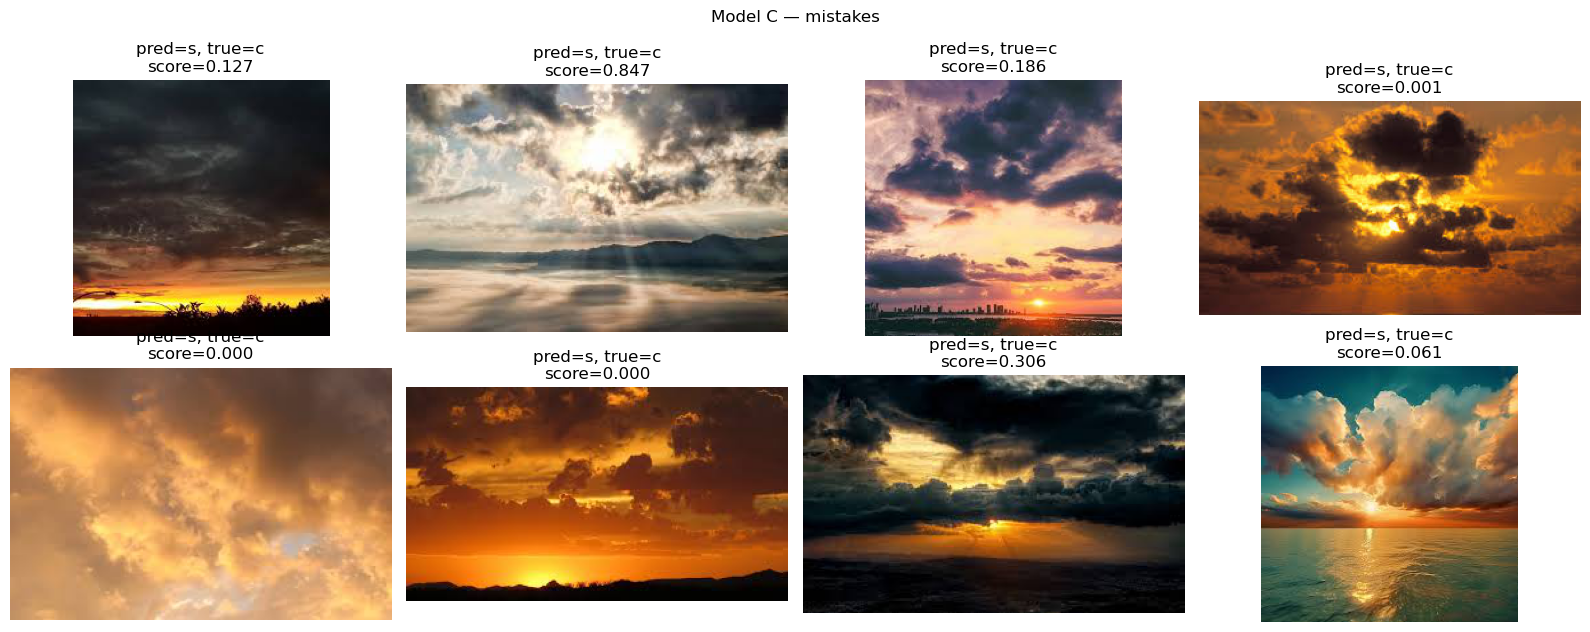

In [19]:
def show_mistakes(samples, preds, scores, title, max_show= 8):
    wrong = [(i, s, preds[i], scores[i]) for i, s in enumerate(samples) if s.label != preds[i]]
    print(f"Misclassified: {len(wrong)}")
    if not wrong:
        return
    cols = 4
    rows = int(math.ceil(min(max_show, len(wrong)) / cols))
    plt.figure(figsize=(4*cols, 3.2*rows))
    for k, (i, smp, pred, sc) in enumerate(wrong[:max_show]):
        plt.subplot(rows, cols, k+1)
        plt.imshow(Image.open(smp.path).convert('RGB'))
        plt.axis('off')
        plt.title(f"pred={pred}, true={smp.label}\nscore={sc:.3f}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_mistakes(samples, pred_A, scores_A, "Model A — mistakes")
show_mistakes(samples, pred_B, scores_B, "Model B — mistakes")
show_mistakes(samples, pred_C, scores_C, "Model C — mistakes")
